In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"habishake","key":"c4bc7ea72a220cbf89f1afe14a11d4c0"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [01:25<00:00, 47.1MB/s]
100% 5.20G/5.20G [01:25<00:00, 65.5MB/s]


In [ ]:
import zipfile

with zipfile.ZipFile("skin-cancer-mnist-ham10000.zip", 'r') as zip_ref:
    zip_ref.extractall("ham10000")


In [ ]:
import shutil

shutil.rmtree("/content/ham10000/ham10000_images_part_1", ignore_errors=True)
shutil.rmtree("/content/ham10000/ham10000_images_part_2", ignore_errors=True)


In [ ]:
import shutil
import os

os.makedirs("all_images", exist_ok=True)

for part in ["HAM10000_images_part_1", "HAM10000_images_part_2"]:
    part_path = f"/content/ham10000/{part}"
    for img_file in os.listdir(part_path):
        shutil.copy(os.path.join(part_path, img_file), "all_images")

In [ ]:
import pandas as pd                                #preprocessing

df = pd.read_csv("/content/ham10000/HAM10000_metadata.csv")

df["image_id"] = df["image_id"] + ".jpg"

available_images = set(os.listdir("all_images"))
df = df[df["image_id"].isin(available_images)]
df


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419.jpg,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030.jpg,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769.jpg,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661.jpg,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633.jpg,bkl,histo,75.0,male,ear
...,...,...,...,...,...,...,...
10010,HAM_0002867,ISIC_0033084.jpg,akiec,histo,40.0,male,abdomen
10011,HAM_0002867,ISIC_0033550.jpg,akiec,histo,40.0,male,abdomen
10012,HAM_0002867,ISIC_0033536.jpg,akiec,histo,40.0,male,abdomen
10013,HAM_0000239,ISIC_0032854.jpg,akiec,histo,80.0,male,face


In [ ]:
from sklearn.preprocessing import LabelEncoder                                #preprocessing

le = LabelEncoder()
df["label"] = le.fit_transform(df["dx"])

label_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label Mapping:", label_map)
df

Label Mapping: {'akiec': np.int64(0), 'bcc': np.int64(1), 'bkl': np.int64(2), 'df': np.int64(3), 'mel': np.int64(4), 'nv': np.int64(5), 'vasc': np.int64(6)}


,lesion_id,image_id,dx,dx_type,age,sex,localization,label
0,HAM_0000118,ISIC_0027419.jpg,bkl,histo,80.0,male,scalp,2
1,HAM_0000118,ISIC_0025030.jpg,bkl,histo,80.0,male,scalp,2
2,HAM_0002730,ISIC_0026769.jpg,bkl,histo,80.0,male,scalp,2
3,HAM_0002730,ISIC_0025661.jpg,bkl,histo,80.0,male,scalp,2
4,HAM_0001466,ISIC_0031633.jpg,bkl,histo,75.0,male,ear,2
...,...,...,...,...,...,...,...,...
10010,HAM_0002867,ISIC_0033084.jpg,akiec,histo,40.0,male,abdomen,0
10011,HAM_0002867,ISIC_0033550.jpg,akiec,histo,40.0,male,abdomen,0
10012,HAM_0002867,ISIC_0033536.jpg,akiec,histo,40.0,male,abdomen,0
10013,HAM_0000239,ISIC_0032854.jpg,akiec,histo,80.0,male,face,0


In [ ]:
from sklearn.model_selection import train_test_split                                #preprocessing

train_df, val_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))

Train size: 8012
Validation size: 2003


In [ ]:
import tensorflow as tf
import numpy as np

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224                                                            #preprocessing
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=20,
    zoom_range=0.2
)

def dataframe_to_generator(df, shuffle=True):
    return datagen.flow_from_dataframe(
        dataframe=df,
        directory="all_images",
        x_col="image_id",
        y_col="label",
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode="raw",
        shuffle=shuffle
    )

train_generator = dataframe_to_generator(train_df)
val_generator   = dataframe_to_generator(val_df, shuffle=False)


Found 8012 validated image filenames.
Found 2003 validated image filenames.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    # Convolutional block 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    # Convolutional block 2
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Convolutional block 3
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Flatten and Dense layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),  # helps prevent overfitting
    Dense(7, activation='softmax')  # 7 classes in HAM10000
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # because labels are integers
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 185s 709ms/step - accuracy: 0.6399 - loss: 1.1923 - val_accuracy: 0.6695 - val_loss: 0.9317
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 164s 655ms/step - accuracy: 0.6750 - loss: 0.9570 - val_accuracy: 0.6765 - val_loss: 0.8744
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 200s 648ms/step - accuracy: 0.6644 - loss: 0.9373 - val_accuracy: 0.6770 - val_loss: 0.8427
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 203s 654ms/step - accuracy: 0.6680 - loss: 0.8877 - val_accuracy: 0.6795 - val_loss: 0.8586
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 163s 648ms/step - accuracy: 0.6803 - loss: 0.8782 - val_accuracy: 0.6765 - val_loss: 0.8488


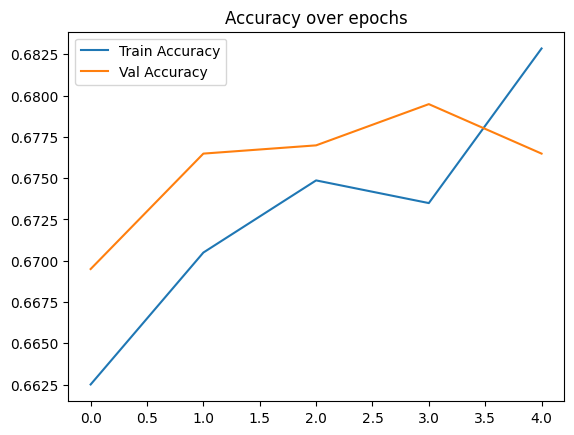

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy over epochs")
plt.show()

In [ ]:
loss, accuracy = model.evaluate(val_generator)
print(f"Validation Accuracy: {accuracy*100:.2f}%")

63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 504ms/step - accuracy: 0.6677 - loss: 0.8628
Validation Accuracy: 67.80%


In [ ]:
uploaded = files.upload()

In [ ]:
from tensorflow.keras.preprocessing import image

# Load the uploaded image (replace 'test.jpg' with your actual file name)
img_path = '/content/Screenshot 2025-05-17 145726.png'

img = image.load_img(img_path, target_size=(224, 224))  # Use your model's input size
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
img_array = img_array / 255.0

In [ ]:
class_labels = {v: k for k, v in label_map.items()}
# Predict
prediction = model.predict(img_array)
predicted_index = np.argmax(prediction)
predicted_class = class_labels[predicted_index]

print("Predicted Class Code:", predicted_class)

disease_labels = {
    "akiec": "Actinic keratoses",
    "bcc": "Basal cell carcinoma",
    "bkl": "Benign keratosis-like lesions",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic nevi",
    "vasc": "Vascular lesions"
}

print("Predicted Skin Disease:", disease_labels.get(predicted_class, "Unknown"))


In [ ]:
from keras.saving import save_model

save_model(model, 'model_1.keras')


In [ ]:
files.download('model_1.keras')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


In [ ]:
# Make a directory (if you haven’t already)
!mkdir -p /content/drive/MyDrive/skin_disease_models

# Save in native Keras format
model.save('/content/drive/MyDrive/skin_disease_models/model_1.keras')


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,509,591 (127.83 MB)

 Trainable params: 11,169,863 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,339,728 (85.22 MB)